# Conformal Test Martingales

## Importing packages

We start by importing some packages needed for this tutorial, in particular the `WrapRegressor` from the main `crepes` module, as well as betting functions and algorithms for generating conformal test martingales from the `crepes.martingales` module.

In [1]:
import numpy as np
import pandas as pd

np.set_printoptions(legacy='1.25')

import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS as colors
colors = list(colors.keys())

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import fetch_openml

import rdkit # Used in the Lipophilicity example; install with "%pip install rdkit"
from rdkit.Chem import AllChem

from crepes import WrapRegressor, __version__

from crepes.martingales import (
    EpsilonBettingFunction,
    StepBettingFunction,
    semi_online_p_values,
    SimpleJumper, 
    SleeperStayer, 
    SleeperDrifter, 
    CompositeMartingale
)

print(f"crepes v. {__version__}")

crepes v. 0.9.0


## Betting functions

A betting function $f: [0, 1] \rightarrow [0, \infty]$ maps p-values to non-negative real numbers such that its integral over the possible p-values equals to one, i.e., $\int_0^1\,f(u)\,du = 1$.

We will here take a look at two betting functions; the `EpsilonBettingFunction` and the `StepBettingFunction`.

#### Epsilon betting function

The epsilon betting function is defined by a parameter $\epsilon$ which determines the slope of the function; given a p-value $p$, the reward is $f_{\epsilon}(p) = 1 + \epsilon (p - 0.5)$. 

We here plot the rewards for five choices of $\epsilon$.

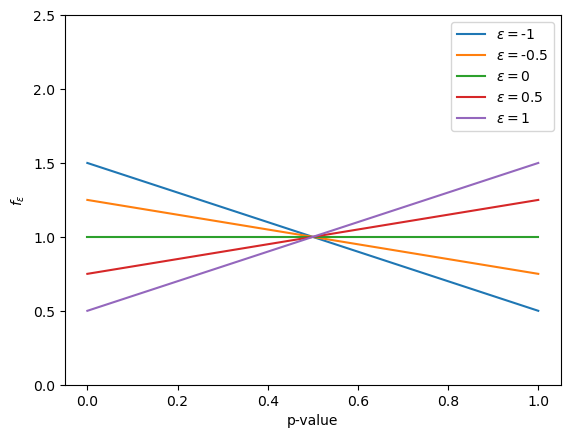

In [2]:
p_values = np.arange(0,1.01,0.01)

E = [-1, -0.5, 0, 0.5, 1]

rewards = EpsilonBettingFunction(E = E).apply(p_values)

for i, epsilon in enumerate(E):
    plt.plot(p_values, rewards[:, i], label=r"$\epsilon = $" + str(epsilon))
    
plt.ylim(0,2.5)
plt.xlabel("p-value")
plt.ylabel(r"$f_{\epsilon}$")
plt.legend()
plt.show()

#### Step betting function

The step betting function is determined by the parameters $a$ and $b$; p-values less than or equal to $a$ will be given a reward of $b/a$, while p-values higher than $a$ will be given a reward of $(1-b)/(1-a)$.

We will here choose values from a grid, where $a$ and $b$ are taken from $\{1/G, \ldots, (G-1)/G \}$ for some value G. 

We set $G = 10$ which hence results in a grid of 81 pairs of values; we visualize the corresponding betting functions for a small subset of these pairs.

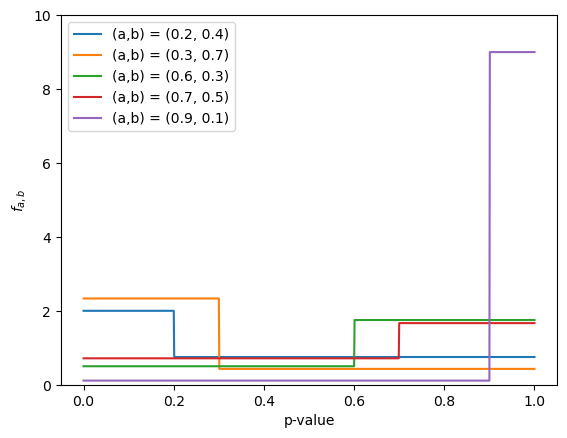

In [3]:
p_values = np.arange(0, 1.001, 0.001)

G = 10

rewards = StepBettingFunction(G=G).apply(p_values)

Gs = [j/G for j in range(1,G)]

pairs = list(enumerate([(a,b) for a in Gs for b in Gs]))

selection = [12, 24, 47, 58, 72]

for i, (a, b) in pairs:
    if i in selection:
        plt.plot(p_values, rewards[:,i], label="(a,b) = "+str((a,b)))

plt.ylim(0,10)
plt.xlabel("p-value")
plt.ylabel("$f_{a,b}$")
plt.legend()
plt.show()

#### Step betting function with drift

We may also employ a step betting function where the threshold is drifting; instead of using a fixed threshold $a$, a weighted average $a \, w + b \, (1 - w)$ may be used where $w$ decreases with the number of observed p-values; the weight $w_i$ for p-value $p_i$ is given by $w_i = (s+1)/(s+i+1)$ where $s$ (the start index) is a parameter. Below, we show the rewards from the step betting function without and with drift, using three different start indices, given a specific p-value and pair of values for $a$ and $b$, varying only the index of the p-value.

It can be seen that for low indices the rewards of the drifting functions are close to the original (non-drifting) step betting function, while the rewards are approaching 1 as the number of observed p-values increase (where the pace depends on the start index). 

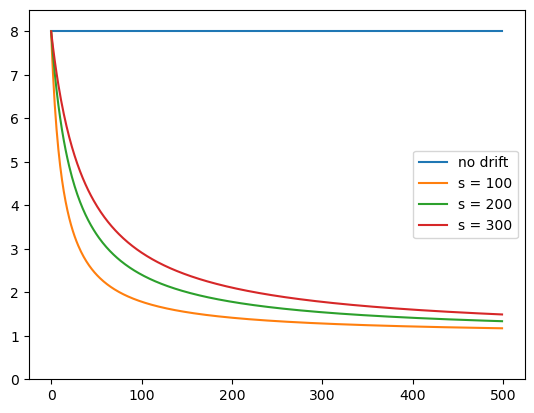

In [4]:
p = 0.05

n = 500

a = 0.1
b = 0.8

Gs = [b]

p_values = np.full(n, p)

rewards_s_100 = StepBettingFunction(Gs = Gs, A = a, s=100).apply(p_values)
rewards_s_200 = StepBettingFunction(Gs = Gs, A = a, s=200).apply(p_values)
rewards_s_300 = StepBettingFunction(Gs = Gs, A = a, s=300).apply(p_values)

rewards_c = StepBettingFunction(Gs = Gs, A = a).apply(p_values)


plt.plot(np.arange(n), rewards_c, label="no drift")

plt.plot(np.arange(n), rewards_s_100, label="s = 100")
plt.plot(np.arange(n), rewards_s_200, label="s = 200")
plt.plot(np.arange(n), rewards_s_300, label="s = 300")

plt.ylim(0,8.5)
plt.legend()
plt.show()

Alternatively, we can create a `StepBettingFunction` without specifying any start index, an instead provide this when calling the `apply` method.

In [5]:
bf = StepBettingFunction(Gs = Gs, A = a)

rewards_s_100 = bf.apply(p_values, s=100)
rewards_s_200 = bf.apply(p_values, s=200)
rewards_s_300 = bf.apply(p_values, s=300)

## Synthethic data

We will consider a scenario, where a sequence of nonconformity scores (of length $n$) is observed, with a random change point (at time $t$), after which the distribution of non-conformity scores changes abruptly; the scores drawn before and after the change come from two different normal distributions. 

You may rerun the example multiple times with other seeds (or just manually modify the means and standard deviations) to see whether the different algorithms are able to detect a violation of the exchangeability assumption. You may also consider using the same distributions, for which the probability of incorrectly signaling for a change is less than or equal to $1/c$, where $c$ is the employed threshold.  

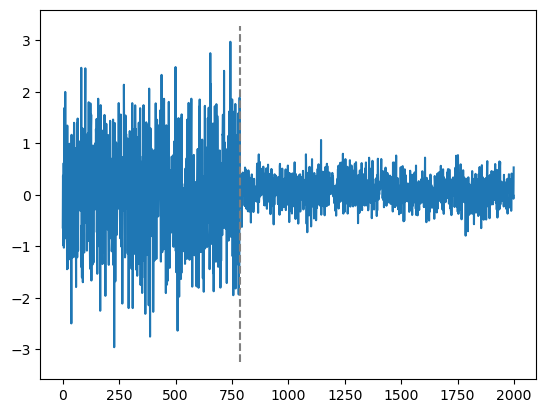

mu_1 = 0 	 std_1 = 1
mu_2 = 0.089 	 std_1 = 0.255


In [6]:
np.random.seed(list(b"ALRW"))

n = 2000                        # Length of sequence

c = 100                         # Threshold to signal drift; P(false alarm) <= 1/c

mu_1 = 0                        # Original mean

std_1 = 1                       # Original standard deviation

t = np.random.randint(1,n-1)    # Random change point

alphas = np.zeros(n)            # Non-conformity scores

alphas[:t] = np.random.randn(t) * std_1 + mu_1

mu_2 = mu_1 + 0.1 * np.random.randn() # Changed mean

std_2 = 1.5 * np.random.rand()  # Changed standard deviation

alphas[t:] = np.random.randn(n-t) * std_2 + mu_2

plt.plot(alphas)

ymin, ymax = plt.axis()[2:]

plt.plot([t, t], [ymin, ymax], linestyle='dashed', c="grey")

plt.show()

print(f"mu_1 = {mu_1} \t std_1 = {std_1}")
print(f"mu_2 = {mu_2:.3f} \t std_1 = {std_2:.3f}")

In order to get p-values from the above non-conformity scores, we employ the function `semi_online_p_values`, i.e., the p-value for each non-conformity score is computed with respect to the preceding non-conformity scores only. If the non-conformity scores would be exchangeable, then the p-values would be independent and uniformly distributed over [0, 1].

In [7]:
p_values = semi_online_p_values(alphas)

We will use the following function for plotting the martingales (after they have been applied to the observed sequence of p-values).

In [8]:
def plot_martingales(all_martingales, change_point=None):
    plt.yscale("log")
    plt.ylim(1e-9, 1e9)
    ymin, ymax = plt.axis()[2:]
    
    signals = []
    early = []
    correct = []
    
    for i, label in enumerate(all_martingales):
        martingales = all_martingales[label]
        plt.plot(np.arange(len(martingales)), martingales, label=label, c=colors[i])
        too_large = np.argwhere(martingales > c)
        if len(too_large) > 0:
            drift_index = too_large[0,0]
            signals.append((drift_index, label))
            if change_point is not None:
                if drift_index >= change_point:
                    correct.append((drift_index, label))
                else:
                    early.append((drift_index, label))
            plt.plot([drift_index, drift_index], [ymin, ymax], linestyle='dotted', 
                     label="_", c=colors[i])
    
    plt.legend()
    
    if change_point is not None:
        plt.plot([change_point, change_point], [ymin, ymax], linestyle='dashed', c="grey")

    plt.show()

    if len(signals) > 0:
        print("Signals:")
        for i, label in sorted(signals):
            print(f"{i} : \t {label}")
        print("")
    
    if len(early) > 0:
        print("Too early:")
        for i, label in sorted(early):
            print(f"{i} : \t {label}")
        print("")
        
    if len(correct) > 0:
        print("Correct:")
        for i, label in sorted(correct):
            print(f"{i} : \t {label}")
        print("")

### Simple Jumper

We first consider martingales generated by two variants of `SimpleJumper`, using the (default) `EpsilonBettingFuntion` and the `StepBettingFunction`, in both cases using the default settings of the betting functions.

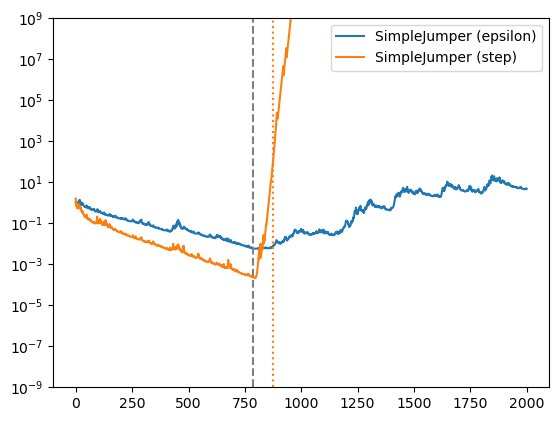

Signals:
875 : 	 SimpleJumper (step)

Correct:
875 : 	 SimpleJumper (step)



In [9]:
martingales_simple_jumper = {
    "SimpleJumper (epsilon)" : SimpleJumper().apply(p_values),
    "SimpleJumper (step)" : SimpleJumper(bf = StepBettingFunction()).apply(p_values),
}

plot_martingales(martingales_simple_jumper, change_point=t)

### Sleeper/Stayer

We also consider martingales generated by `SleeperStayer`, again using the `EpsilonBettingFuntion` and the (default) `StepBettingFunction`.

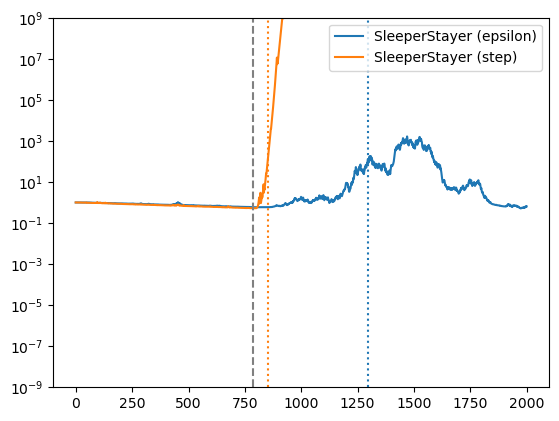

Signals:
852 : 	 SleeperStayer (step)
1295 : 	 SleeperStayer (epsilon)

Correct:
852 : 	 SleeperStayer (step)
1295 : 	 SleeperStayer (epsilon)



In [10]:
martingales_sleeper_stayer = {
    "SleeperStayer (epsilon)" : SleeperStayer(bf = EpsilonBettingFunction()).apply(p_values),
    "SleeperStayer (step)" : SleeperStayer().apply(p_values),
}

plot_martingales(martingales_sleeper_stayer, change_point=t)

### Sleeper/Drifter

Below we plot the martingales generated by `SleeperDrifter` for three betting functions. In addition to the `EpsilonBettingFuntion` and non-drifting `StepBettingFunction` that were used above, the latter is used also with drift, which is the default for Sleeper/Drifter. The `apply` method of the `StepBettingFunction` is called with a start index by default, when used within `SleeperDrifter`.

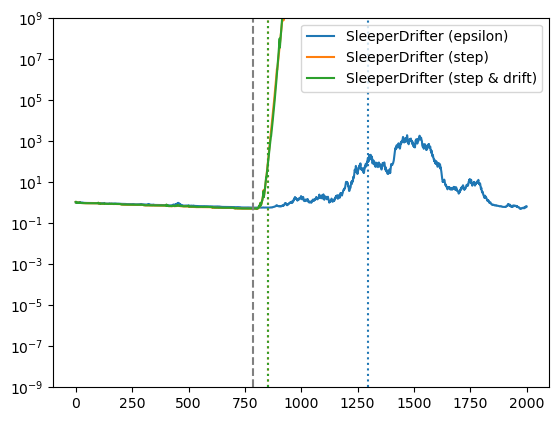

Signals:
853 : 	 SleeperDrifter (step)
854 : 	 SleeperDrifter (step & drift)
1294 : 	 SleeperDrifter (epsilon)

Correct:
853 : 	 SleeperDrifter (step)
854 : 	 SleeperDrifter (step & drift)
1294 : 	 SleeperDrifter (epsilon)



In [11]:
martingales_sleeper_drifter = {
    "SleeperDrifter (epsilon)" : SleeperDrifter(bf = EpsilonBettingFunction()).apply(p_values),
    "SleeperDrifter (step)" : SleeperDrifter(bf = StepBettingFunction(), drift=False).apply(p_values),
    "SleeperDrifter (step & drift)" : SleeperDrifter(bf = StepBettingFunction()).apply(p_values),
}

plot_martingales(martingales_sleeper_drifter, change_point=t)

### Composite martingale

We may also form a martingale by averaging the output of multiple martingales; this can be done using a `CompositeMartingale` which upon creation takes a list of martingales as input.

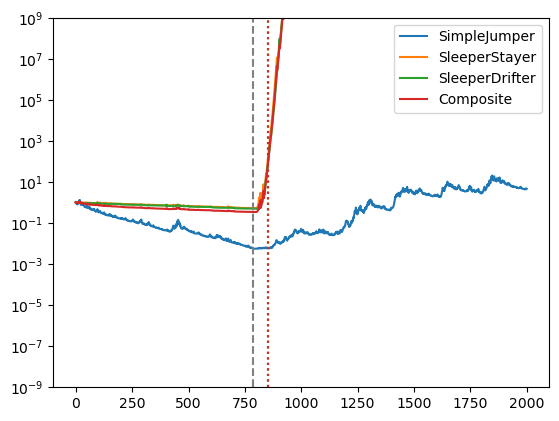

Signals:
852 : 	 SleeperStayer
854 : 	 Composite
854 : 	 SleeperDrifter

Correct:
852 : 	 SleeperStayer
854 : 	 Composite
854 : 	 SleeperDrifter



In [12]:
martingales = [SimpleJumper(), SleeperStayer(), SleeperDrifter()]

martingales_composite = {
    "SimpleJumper" : martingales[0].apply(p_values),
    "SleeperStayer" : martingales[1].apply(p_values),
    "SleeperDrifter" : martingales[2].apply(p_values),
    "Composite" : CompositeMartingale(martingales).apply(p_values),
}

plot_martingales(martingales_composite, change_point=t)

## Real-world datasets

We will also illustrate the generation of martingales using a couple of real-world dataset, for which we however do not know if there is any data drift; we will just rely on the ability of the algorithms to control the false alarm rate. We will re-use the threshold $c = 100$ that we set above, which means that the probability of observing a martingale higher than this is less than $1/c$ if the assumption of exchangeability holds. You may consider repeating the below investigations with randomly shuffled datasets for which you should not expect to detect any data drift (assuming that a sufficiently large $c$ has been chosen).

### House pricing

We first import the house sales dataset from [www.openml.org](https://www.openml.org/), and sort it based on year, month and day, after which these features are removed. We devise a training set from the 10 000 first instances and put the remaining instances in the test set. 

In [13]:
np.random.seed(2025)

dataset = fetch_openml(name="house_sales", version=3, parser="auto")

sorted_index = dataset.data.sort_values(["date_year", 
                                         "date_month", 
                                         "date_day"]).index

# Uncomment the following if you want to investigate what happens when 
# the dataset is randomly shuffled

#sorted_index = np.random.choice(np.arange(len(dataset.data)), 
#                                len(dataset.data), 
#                                replace=False)

X = dataset.data.loc[sorted_index].drop(["date_year", 
                                         "date_month", 
                                         "date_day"], 
                                        axis="columns").values.astype(float)

y = dataset.target.loc[sorted_index].values.astype(float)

test_start = 10000

X_train = X[:test_start]
y_train = y[:test_start]
X_test = X[test_start:]
y_test = y[test_start:]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (10000, 18)
y_train: (10000,)
X_test: (11613, 18)
y_test: (11613,)


We wrap a `RandomForestRegressor`, fit it using the training set, and then form a conformal predictive system with an initially empty calibration set.
The calibration set is extended with each test instance in turn, after having generated a p-value for it, i.e., the p-values are computed in the semi-online mode.

In [14]:
rf = WrapRegressor(RandomForestRegressor(n_jobs=-1))

rf.fit(X_train, y_train)

rf.calibrate(cps=True)

p_values = rf.predict_p(X_test, y_test, online=True)

Below we plot the martingales generated from this sequence of p-values, using the same set of algorithms as used above.

### Simple Jumper

In addition to using two alternative betting functions with `SimpleJumper`, we also compare the default jumping rate ($J = 0.01$) to one that may work better for longer sequences with no drift, i.e., $J = 0.0001$.

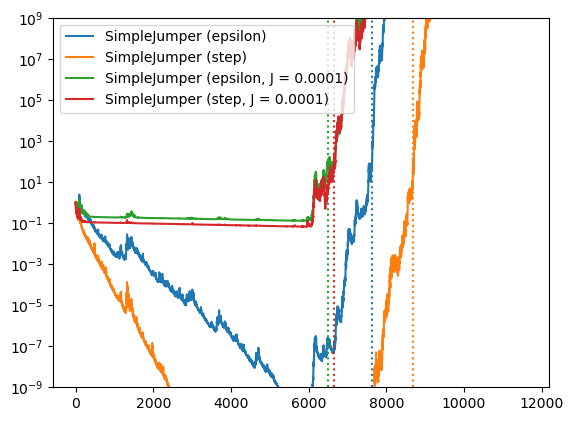

Signals:
6508 : 	 SimpleJumper (epsilon, J = 0.0001)
6650 : 	 SimpleJumper (step, J = 0.0001)
7633 : 	 SimpleJumper (epsilon)
8683 : 	 SimpleJumper (step)



In [15]:
martingales_simple_jumper = {
    "SimpleJumper (epsilon)" : SimpleJumper().apply(p_values),
    "SimpleJumper (step)" : SimpleJumper(bf = StepBettingFunction()).apply(p_values),
    "SimpleJumper (epsilon, J = 0.0001)" : SimpleJumper(J = 0.0001).apply(p_values),
    "SimpleJumper (step, J = 0.0001)" : SimpleJumper(J = 0.0001, bf = StepBettingFunction()).apply(p_values),
}

plot_martingales(martingales_simple_jumper)

### Sleeper/Stayer

We use the two betting functions also with `SleeperStayer`, and compare using the default investment rate ($R = 0.001$) with $R = 0.0001$.

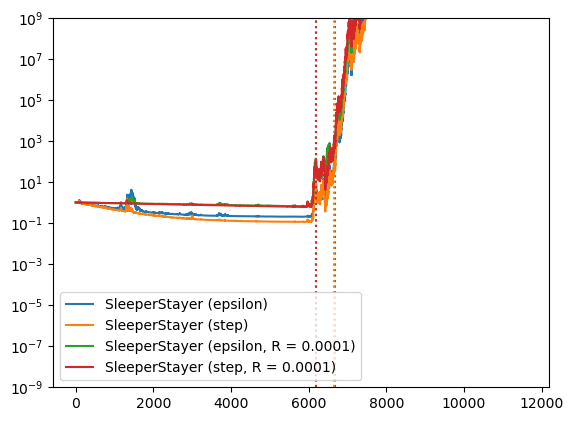

Signals:
6180 : 	 SleeperStayer (epsilon, R = 0.0001)
6181 : 	 SleeperStayer (step, R = 0.0001)
6653 : 	 SleeperStayer (step)
6685 : 	 SleeperStayer (epsilon)



In [16]:
martingales_sleeper_stayer = {
    "SleeperStayer (epsilon)" : SleeperStayer(bf = EpsilonBettingFunction()).apply(p_values),
    "SleeperStayer (step)" : SleeperStayer().apply(p_values),
    "SleeperStayer (epsilon, R = 0.0001)" : SleeperStayer(R = 0.0001, bf = EpsilonBettingFunction()).apply(p_values),
    "SleeperStayer (step, R = 0.0001)" : SleeperStayer(R = 0.0001).apply(p_values),
}

plot_martingales(martingales_sleeper_stayer)

### Sleeper/Drifter

We also compare the default investment rate ($R = 0.1$) to $R = 0.01$ for `SleeperDrifter`, in conjunction with three different betting functions.

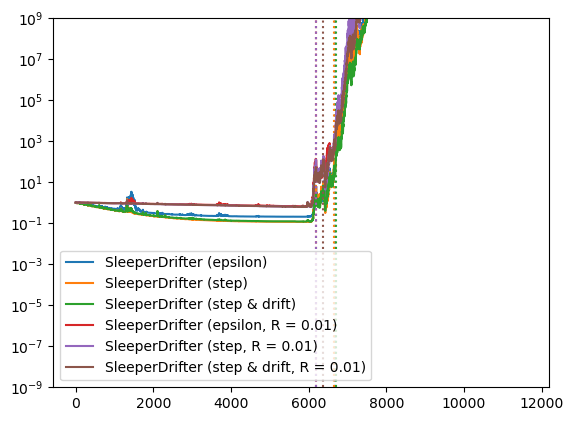

Signals:
6180 : 	 SleeperDrifter (epsilon, R = 0.01)
6181 : 	 SleeperDrifter (step, R = 0.01)
6371 : 	 SleeperDrifter (step & drift, R = 0.01)
6654 : 	 SleeperDrifter (step)
6688 : 	 SleeperDrifter (epsilon)
6696 : 	 SleeperDrifter (step & drift)



In [17]:
martingales_sleeper_drifter = {
    "SleeperDrifter (epsilon)" : SleeperDrifter(bf = EpsilonBettingFunction()).apply(p_values),
    "SleeperDrifter (step)" : SleeperDrifter(bf = StepBettingFunction(), drift=False).apply(p_values),
    "SleeperDrifter (step & drift)" : SleeperDrifter(bf = StepBettingFunction()).apply(p_values),
    "SleeperDrifter (epsilon, R = 0.01)" : SleeperDrifter(R = 0.01, bf = EpsilonBettingFunction()).apply(p_values),
    "SleeperDrifter (step, R = 0.01)" : SleeperDrifter(R = 0.01, bf = StepBettingFunction(), drift=False).apply(p_values),
    "SleeperDrifter (step & drift, R = 0.01)" : SleeperDrifter(R = 0.01, bf = StepBettingFunction()).apply(p_values),
}

plot_martingales(martingales_sleeper_drifter)

### Composite martingale

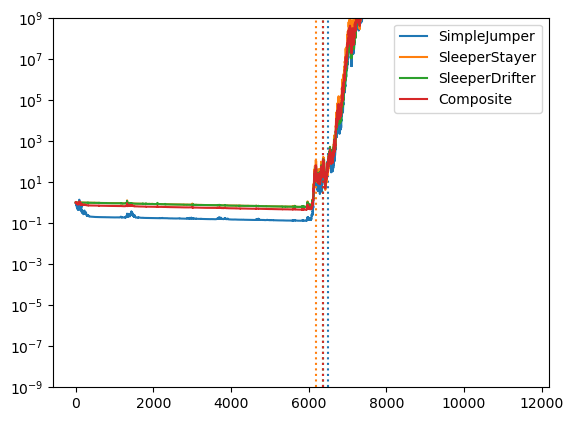

Signals:
6181 : 	 SleeperStayer
6371 : 	 SleeperDrifter
6372 : 	 Composite
6508 : 	 SimpleJumper



In [18]:
martingales = [SimpleJumper(J = 0.0001), SleeperStayer(R = 0.0001), SleeperDrifter(R = 0.01)]

martingales_composite = {
    "SimpleJumper" : martingales[0].apply(p_values),
    "SleeperStayer" : martingales[1].apply(p_values),
    "SleeperDrifter" : martingales[2].apply(p_values),
    "Composite" : CompositeMartingale(martingales).apply(p_values),
}

plot_martingales(martingales_composite)

### Lipophilicity

Finally, we consider another real-world dataset, concerning the prediction of the chemical property lipophilicity, based on binary features, generated from so-called SMILES strings, using the `rdkit` package. Before splitting the data into a training and test set, using the first 2000 instances for the former, we sort the dataset according to the ChEMBL identifier.

The p-values for the test set are as above obtained using a conformal predictive system with semi-online calibration, i.e., the underlying model obtained from the training set stays the same, while the calibration set is iteratively updated.

In [19]:
np.random.seed(2025)

url = ("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/"
       "Lipophilicity.csv")

df = pd.read_csv(url)
df["No"] = [int(s.split("CHEMBL")[1]) for s in df["CMPD_CHEMBLID"]]

df = df.sort_values("No")

y = df["exp"].values

molecules = [rdkit.Chem.MolFromSmiles(s) for s in df["smiles"]]

fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)

X = np.array([fpgen.GetFingerprint(m) for m in molecules])

# Uncomment the following if you want to investigate what happens 
# when the dataset is randomly shuffled

#random_index = np.random.choice(np.arange(len(df)), 
#                                len(df), replace=False)
#X = X[random_index]
#y = y[random_index]

test_start = 2000

X_train = X[:test_start]
y_train = y[:test_start]
X_test = X[test_start:]
y_test = y[test_start:]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

rf = WrapRegressor(RandomForestRegressor(n_jobs=-1))
rf.fit(X_train, y_train)
rf.calibrate(cps=True)
p_values = rf.predict_p(X_test, y_test, online=True)

X_train: (2000, 1024)
y_train: (2000,)
X_test: (2200, 1024)
y_test: (2200,)


### Simple Jumper

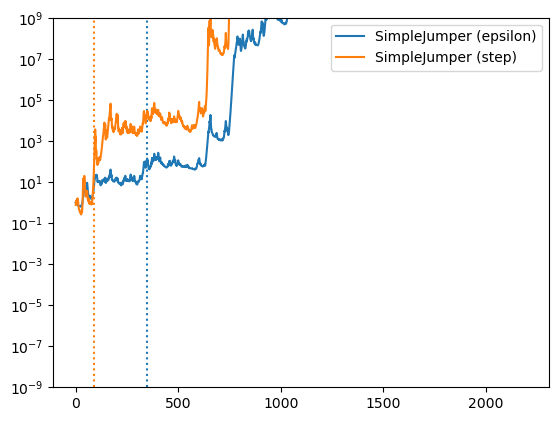

Signals:
90 : 	 SimpleJumper (step)
347 : 	 SimpleJumper (epsilon)



In [20]:
martingales_simple_jumper = {
    "SimpleJumper (epsilon)" : SimpleJumper().apply(p_values),
    "SimpleJumper (step)" : SimpleJumper(bf = StepBettingFunction()).apply(p_values),
}

plot_martingales(martingales_simple_jumper)

### Sleeper/Stayer

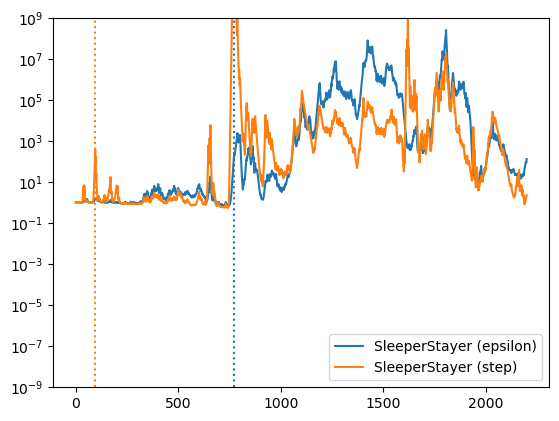

Signals:
94 : 	 SleeperStayer (step)
770 : 	 SleeperStayer (epsilon)



In [21]:
martingales_sleeper_stayer = {
    "SleeperStayer (epsilon)" : SleeperStayer(bf = EpsilonBettingFunction()).apply(p_values),
    "SleeperStayer (step)" : SleeperStayer().apply(p_values),
}

plot_martingales(martingales_sleeper_stayer)

### Sleeper/Drifter

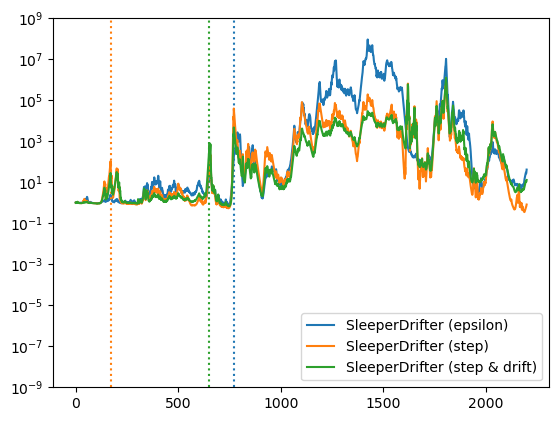

Signals:
170 : 	 SleeperDrifter (step)
648 : 	 SleeperDrifter (step & drift)
770 : 	 SleeperDrifter (epsilon)



In [22]:
martingales_sleeper_drifter = {
    "SleeperDrifter (epsilon)" : SleeperDrifter(bf = EpsilonBettingFunction()).apply(p_values),
    "SleeperDrifter (step)" : SleeperDrifter(bf = StepBettingFunction(), drift=False).apply(p_values),
    "SleeperDrifter (step & drift)" : SleeperDrifter(bf = StepBettingFunction()).apply(p_values),
}

plot_martingales(martingales_sleeper_drifter)

### Composite martingale

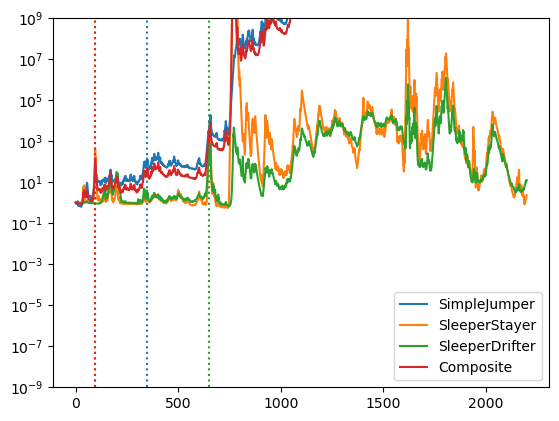

Signals:
94 : 	 SleeperStayer
95 : 	 Composite
347 : 	 SimpleJumper
648 : 	 SleeperDrifter



In [23]:
martingales = [SimpleJumper(), SleeperStayer(), SleeperDrifter()]

martingales_composite = {
    "SimpleJumper" : martingales[0].apply(p_values),
    "SleeperStayer" : martingales[1].apply(p_values),
    "SleeperDrifter" : martingales[2].apply(p_values),
    "Composite" : CompositeMartingale(martingales).apply(p_values),
}

plot_martingales(martingales_composite)